## Project layout

Resolve the repo subdirectories so the rest of the notebook is
cwd-independent and figures land in the shared `figures/` folder.


In [1]:
# Project layout: notebooks live in <root>/notebooks/, source in
# <root>/src/, persistent datasets in <root>/data/, saved figures in
# <root>/figures/. We resolve these once so the rest of the notebook is
# cwd-independent.
from pathlib import Path
import sys

REPO_ROOT   = Path.cwd().resolve().parent
SRC_DIR     = REPO_ROOT / 'src'
DATA_DIR    = REPO_ROOT / 'data'
FIGURES_DIR = REPO_ROOT / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# Figures and analysis

Reads from the main-sweep HDF5 and the summary CSVs to produce the figures
for the paper. The interactive widget reads the main sweep; the static
figures use the summary CSVs.

In [2]:
import os
import warnings

import h5py
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import VBox, Output
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')

RHO_SW      = 1024.0
MAIN_HDF5   = DATA_DIR / 'groundwater_sweep_profiles.h5'
SUMMARY_CSV = DATA_DIR / 'groundwater_sweep_summary.csv'
SENS_CSV    = DATA_DIR / 'geometry_sensitivity_summary.csv'

## Interactive spatial gradient viewer (main sweep)

In [3]:
# Build a parameter-tuple → group-name lookup once so slider changes don't
# linearly scan all runs each time.
_param_to_group = {}
with h5py.File(MAIN_HDF5, 'r') as hf:
    _x_km        = hf['x_coords_m'][:] / 1000.0
    _in_mud_zone = hf['in_mud_zone'][:]
    for grp_name in hf['runs']:
        a = hf['runs'][grp_name].attrs
        _param_to_group[(
            float(a['overpressure_mpa']),
            float(a['k_mud_m2']),
            float(a['k_sand_m2']),
            float(a['ovp_thickness_m']),
        )] = grp_name
print(f'{len(_param_to_group)} runs available.')

_all_op = sorted({k[0] for k in _param_to_group})
_all_km = sorted({k[1] for k in _param_to_group})
_all_ks = sorted({k[2] for k in _param_to_group})
_all_ot = sorted({k[3] for k in _param_to_group})

6435 runs available.


In [4]:
def _closest(target, options):
    return min(options, key=lambda v: abs(v - target))

def _load(op, km, ks, ot):
    key = (
        _closest(op, _all_op),
        _closest(km, _all_km),
        _closest(ks, _all_ks),
        _closest(ot, _all_ot),
    )
    grp_name = _param_to_group.get(key)
    if grp_name is None:
        return None, None
    with h5py.File(MAIN_HDF5, 'r') as hf:
        g = hf['runs'][grp_name]
        return g['time_yr'][:].astype(np.float32), g['gradients'][:].astype(np.float32)

def _mk_slider(opts, fmt, desc, default=None):
    return widgets.SelectionSlider(
        options=[(fmt(v), v) for v in opts],
        value=default if default is not None else opts[len(opts) // 2],
        description=desc,
        layout=widgets.Layout(width='660px'),
        style={'description_width': '110px'},
        continuous_update=False,
    )

op_slider       = _mk_slider(_all_op, lambda v: f'{v:.2f} MPa', 'Overpressure:')
mud_slider      = _mk_slider(_all_km, lambda v: f'{v:.0e} m²',  'k_mud:')
sand_slider     = _mk_slider(_all_ks, lambda v: f'{v:.0e} m²',  'k_sand:')
ot_slider       = _mk_slider(_all_ot, lambda v: f'{v:.0f} m',   'OVP thickness:')
rho_mud_slider  = _mk_slider([1300, 1400, 1500, 1600, 1650, 1700, 1800, 1900], lambda v: f'{v:,} kg/m³', 'ρ_mud:',  default=1650)
rho_sand_slider = _mk_slider([1800, 1900, 2000, 2100, 2150, 2200],             lambda v: f'{v:,} kg/m³', 'ρ_sand:', default=2150)
time_slider     = widgets.IntSlider(min=0, max=1, step=1, value=0, description='Time step:', layout=widgets.Layout(width='660px'), style={'description_width': '110px'})
ymax_slider     = widgets.FloatSlider(min=0.05, max=5.0, step=0.05, value=1.0, description='Y-axis max:', layout=widgets.Layout(width='660px'), style={'description_width': '110px'})
plot_out        = Output()

_cache = {'key': None, 'times': None, 'grads': None}
def _get():
    key = (op_slider.value, mud_slider.value, sand_slider.value, ot_slider.value)
    if _cache['key'] != key:
        _cache['times'], _cache['grads'] = _load(*key)
        _cache['key'] = key
    return _cache['times'], _cache['grads']

def _redraw(*_):
    times, grads = _get()
    with plot_out:
        plot_out.clear_output(wait=True)
        if times is None:
            print('Run not found.')
            return
        time_slider.max = len(times) - 1
        step = min(time_slider.value, len(times) - 1)
        t = times[step]
        profile = grads[step]
        crit_mud  = (rho_mud_slider.value  - RHO_SW) / RHO_SW
        crit_sand = (rho_sand_slider.value - RHO_SW) / RHO_SW
        fig, ax = plt.subplots(figsize=(11, 4.5))
        ax.plot(_x_km, profile, color='#1565c0', lw=1.8)
        ax.axhline(crit_mud,  color='#2e7d32', lw=1.4, ls='--', label=f'Crit mud ({crit_mud:.3f})')
        ax.axhline(crit_sand, color='#e65100', lw=1.4, ls='--', label=f'Crit sand ({crit_sand:.3f})')
        ax.set_xlabel('Horizontal position (km)')
        ax.set_ylabel('Surface gradient (−)')
        ax.set_ylim(0, ymax_slider.value)
        ax.set_title(f'OP={op_slider.value:.2f}MPa  k_mud={mud_slider.value:.0e}m²  k_sand={sand_slider.value:.0e}m²  OVP={ot_slider.value:.0f}m  t={t:g}yr')
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, lw=0.4, color='#ccc')
        fig.tight_layout()
        plt.show()

for sl in (op_slider, mud_slider, sand_slider, ot_slider, rho_mud_slider, rho_sand_slider, time_slider, ymax_slider):
    sl.observe(_redraw, names='value')
_redraw()
display(VBox([op_slider, mud_slider, sand_slider, ot_slider, rho_mud_slider, rho_sand_slider, ymax_slider, time_slider, plot_out]))

## Main-sweep parameter sensitivity


In [5]:
df = pd.read_csv(SUMMARY_CSV)
print(f'{len(df):,} rows loaded from summary CSV.')
df.head()


413,010 rows loaded from summary CSV.


,overpressure_mpa,k_mud_m2,k_sand_m2,ovp_thickness_m,bulkrho_mud_kg_m3,bulkrho_sand_kg_m3,crit_grad_mud,crit_grad_sand,peak_gradient_mud,peak_gradient_sand,...,first_exceed_yr_mud,last_exceed_yr_mud,n_timesteps_exceed_mud,any_exceed_sand,first_exceed_yr_sand,last_exceed_yr_sand,n_timesteps_exceed_sand,n_timesteps,time_start_yr,time_end_yr
0,1.55,1.000000e-20,1.000000e-13,15.9,1300,1800,0.269531,0.757812,3.893418,3.907596,...,0.1,29995.0,502,True,0.1,16295.0,365,503,0.0,29995.0
1,1.55,1.000000e-20,1.000000e-13,15.9,1300,1850,0.269531,0.806641,3.893418,3.907596,...,0.1,29995.0,502,True,0.1,15695.0,359,503,0.0,29995.0
2,1.55,1.000000e-20,1.000000e-13,15.9,1300,1900,0.269531,0.855469,3.893418,3.907596,...,0.1,29995.0,502,True,0.1,15095.0,353,503,0.0,29995.0
3,1.55,1.000000e-20,1.000000e-13,15.9,1300,1950,0.269531,0.904297,3.893418,3.907596,...,0.1,29995.0,502,True,0.1,14595.0,348,503,0.0,29995.0
4,1.55,1.000000e-20,1.000000e-13,15.9,1300,2000,0.269531,0.953125,3.893418,3.907596,...,0.1,29995.0,502,True,0.1,13995.0,342,503,0.0,29995.0


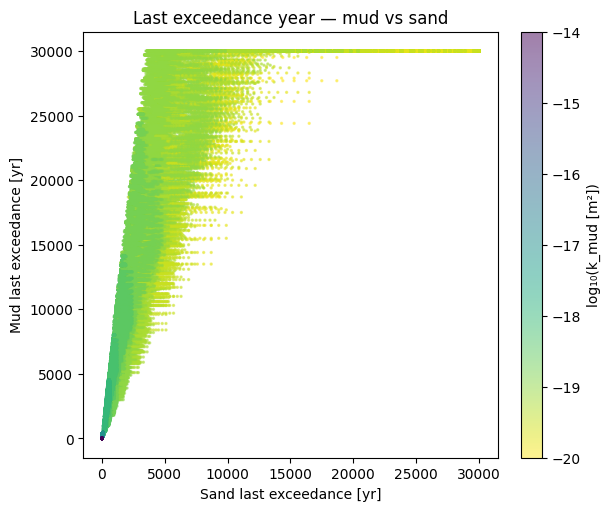

In [6]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sc = ax.scatter(
    df['last_exceed_yr_sand'], df['last_exceed_yr_mud'],
    c=np.log10(df['k_mud_m2']), cmap='viridis_r', s=2, alpha=0.5,
)
plt.colorbar(sc, ax=ax, label='log₁₀(k_mud [m²])')
ax.set_xlabel('Sand last exceedance [yr]')
ax.set_ylabel('Mud last exceedance [yr]')
ax.set_title('Last exceedance year — mud vs sand')
plt.savefig(FIGURES_DIR / 'fig_main_last_exceedance_scatter.png', dpi=200, bbox_inches='tight')
plt.show()


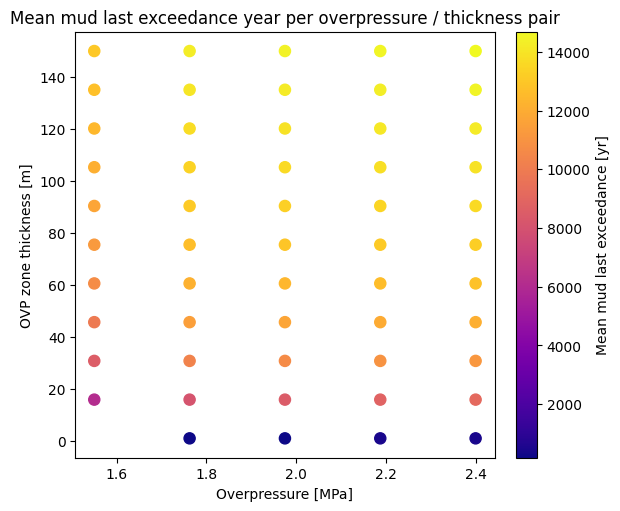

In [7]:
grouped = df.groupby(['overpressure_mpa', 'ovp_thickness_m'])['last_exceed_yr_mud'].mean().reset_index()
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sc = ax.scatter(grouped['overpressure_mpa'], grouped['ovp_thickness_m'],
                c=grouped['last_exceed_yr_mud'], cmap='plasma', s=64)
plt.colorbar(sc, ax=ax, label='Mean mud last exceedance [yr]')
ax.set_xlabel('Overpressure [MPa]')
ax.set_ylabel('OVP zone thickness [m]')
ax.set_title('Mean mud last exceedance year per overpressure / thickness pair')
plt.savefig(FIGURES_DIR / 'fig_main_overpressure_thickness_exceedance.png', dpi=200, bbox_inches='tight')
plt.show()


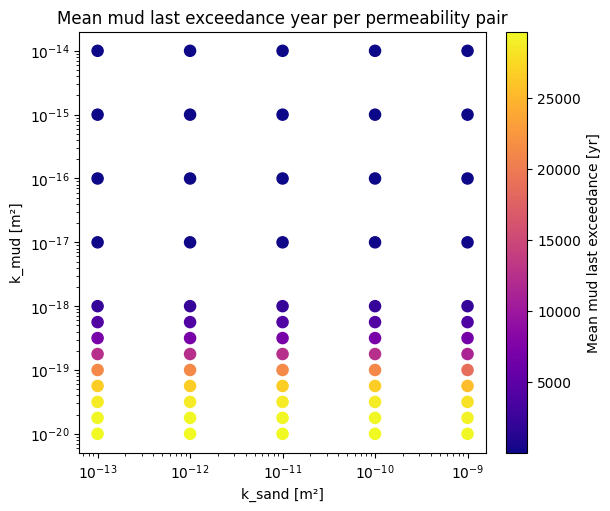

In [8]:
grouped = df.groupby(['k_sand_m2', 'k_mud_m2'])['last_exceed_yr_mud'].mean().reset_index()
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
sc = ax.scatter(grouped['k_sand_m2'], grouped['k_mud_m2'],
                c=grouped['last_exceed_yr_mud'], cmap='plasma', s=64)
plt.colorbar(sc, ax=ax, label='Mean mud last exceedance [yr]')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('k_sand [m²]'); ax.set_ylabel('k_mud [m²]')
ax.set_title('Mean mud last exceedance year per permeability pair')
plt.savefig(FIGURES_DIR / 'fig_main_permeability_exceedance.png', dpi=200, bbox_inches='tight')
plt.show()


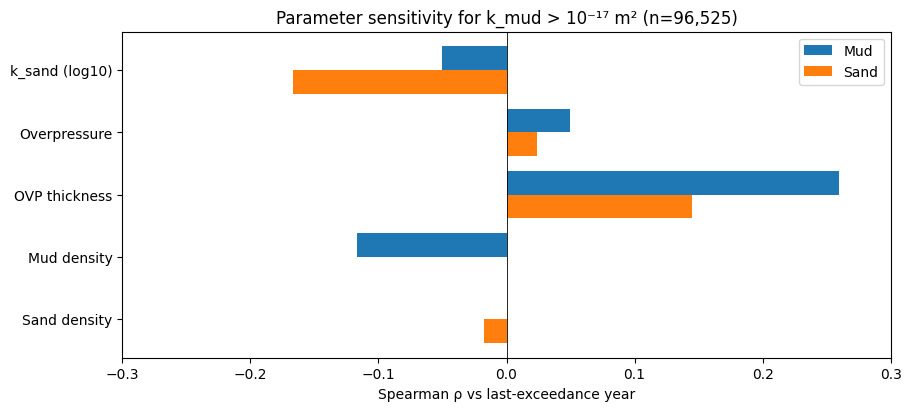

In [9]:
from scipy.stats import spearmanr

k_mud_cutoff = 1e-17
df_hi = df[df['k_mud_m2'] > k_mud_cutoff]

params_rho = [
    ('k_sand_m2',          'k_sand (log10)', True,  ('mud', 'sand')),
    ('overpressure_mpa',   'Overpressure',   False, ('mud', 'sand')),
    ('ovp_thickness_m',    'OVP thickness',  False, ('mud', 'sand')),
    ('bulkrho_mud_kg_m3',  'Mud density',    False, ('mud',)),
    ('bulkrho_sand_kg_m3', 'Sand density',   False, ('sand',)),
]

def _rho(x, y):
    mask = x.notna() & y.notna()
    if mask.sum() < 3 or x[mask].nunique() < 2:
        return np.nan
    return spearmanr(x[mask], y[mask]).correlation

C0, C1 = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]
labels, muds, sands = [], [], []
for col, lbl, log, series in params_rho:
    x = np.log10(df_hi[col]) if log else df_hi[col]
    labels.append(lbl)
    muds.append(_rho(x, df_hi['last_exceed_yr_mud'])   if 'mud'  in series else np.nan)
    sands.append(_rho(x, df_hi['last_exceed_yr_sand']) if 'sand' in series else np.nan)

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
y_pos = np.arange(len(labels))
ax.barh(y_pos - 0.19, muds,  0.38, label='Mud',  color=C0)
ax.barh(y_pos + 0.19, sands, 0.38, label='Sand', color=C1)
ax.axvline(0, color='k', lw=0.6)
ax.set_yticks(y_pos); ax.set_yticklabels(labels); ax.invert_yaxis()
ax.set_xlabel('Spearman ρ vs last-exceedance year')
ax.set_xlim(-0.3, 0.3); ax.legend()
ax.set_title(f'Parameter sensitivity for k_mud > 10⁻¹⁷ m² (n={len(df_hi):,})')
plt.savefig(FIGURES_DIR / 'fig_main_spearman.png', dpi=200, bbox_inches='tight')
plt.show()


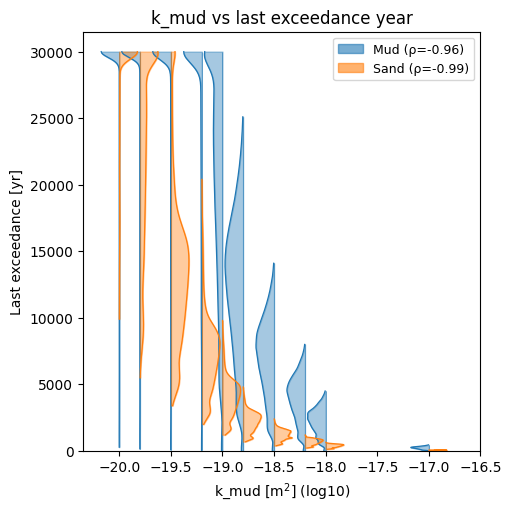

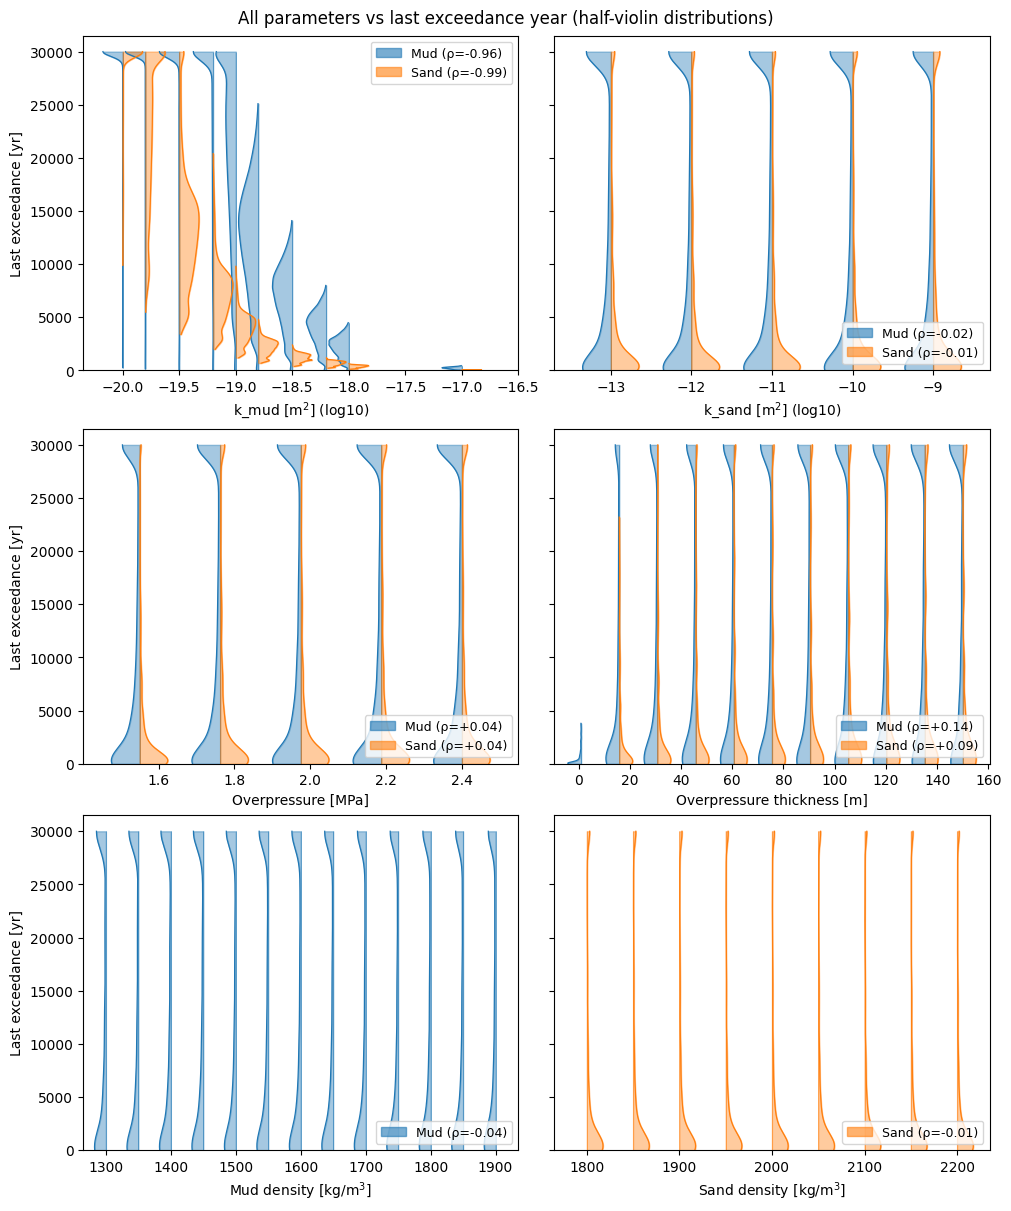

In [10]:
from scipy.stats import gaussian_kde

params_violin = [
    ('k_mud_m2',           r'k_mud [m$^2$] (log10)',     True,  ('mud', 'sand')),
    ('k_sand_m2',          r'k_sand [m$^2$] (log10)',    True,  ('mud', 'sand')),
    ('overpressure_mpa',   'Overpressure [MPa]',          False, ('mud', 'sand')),
    ('ovp_thickness_m',    'Overpressure thickness [m]',  False, ('mud', 'sand')),
    ('bulkrho_mud_kg_m3',  r'Mud density [kg/m$^3$]',     False, ('mud',)),
    ('bulkrho_sand_kg_m3', r'Sand density [kg/m$^3$]',    False, ('sand',)),
]
C0, C1 = plt.rcParams['axes.prop_cycle'].by_key()['color'][:2]

def _half_violins(ax, x_positions, y_groups, color, width, side='left'):
    sign = -1 if side == 'left' else 1
    for xc, ys in zip(x_positions, y_groups):
        ys = np.asarray(ys).ravel()
        ys = ys[~np.isnan(ys)]
        if len(ys) < 3 or np.ptp(ys) == 0:
            continue
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(ys, bw_method='scott')
        y_grid = np.linspace(ys.min(), ys.max(), 300)
        d = kde(y_grid)
        d = d / d.max() * (width / 2)
        ax.fill_betweenx(y_grid, xc, xc + sign * d, alpha=0.4, color=color)
        ax.plot(xc + sign * d, y_grid, lw=0.9, color=color)
        ax.vlines(xc, ys.min(), ys.max(), color=color, lw=0.7, alpha=0.5)

def _draw_violin_ax(ax, col, label, log, series, is_first=False):
    df_tmp = df.assign(_x=np.log10(df[col]).round(1) if log else df[col])
    unique_x = np.sort(df_tmp['_x'].dropna().unique())
    if len(unique_x) < 2:
        ax.text(0.5, 0.5, 'not enough variation', ha='center', va='center', transform=ax.transAxes)
        ax.set_xlabel(label); return
    width = (unique_x[-1] - unique_x[0]) / max(len(unique_x) - 1, 1) * 0.7
    handles = []
    if 'mud' in series:
        groups = [df_tmp.loc[df_tmp['_x'] == xv, 'last_exceed_yr_mud'].values for xv in unique_x]
        _half_violins(ax, unique_x, groups, C0, width, side='left')
        rho = _rho(df_tmp['_x'], df_tmp['last_exceed_yr_mud'])
        handles.append(plt.matplotlib.patches.Patch(color=C0, alpha=0.6, label=f'Mud (ρ={rho:+.2f})'))
    if 'sand' in series:
        groups = [df_tmp.loc[df_tmp['_x'] == xv, 'last_exceed_yr_sand'].values for xv in unique_x]
        _half_violins(ax, unique_x, groups, C1, width, side='right')
        rho = _rho(df_tmp['_x'], df_tmp['last_exceed_yr_sand'])
        handles.append(plt.matplotlib.patches.Patch(color=C1, alpha=0.6, label=f'Sand (ρ={rho:+.2f})'))
    ax.set_xlabel(label)
    ax.set_xlim(unique_x[0] - width, unique_x[-1] + width)
    if col == 'k_mud_m2':
        ax.set_xlim(ax.get_xlim()[0], -16.5)
    ax.legend(handles=handles, loc='upper right' if is_first else 'lower right', fontsize=9)
    ax.set_ylim(bottom=0)

# Standalone first subplot (k_mud)
col0, lbl0, log0, ser0 = params_violin[0]
fig1, ax1 = plt.subplots(figsize=(5, 5), constrained_layout=True)
_draw_violin_ax(ax1, col0, lbl0, log0, ser0, is_first=True)
ax1.set_ylabel('Last exceedance [yr]')
ax1.set_title('k_mud vs last exceedance year')
plt.savefig(FIGURES_DIR / 'fig_main_violin_kmud.png', dpi=200, bbox_inches='tight')
plt.show()

# Full 3×2 grid
fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharey=True, constrained_layout=True)
for idx, (ax, (col, label, log, series)) in enumerate(zip(axes.flat, params_violin)):
    _draw_violin_ax(ax, col, label, log, series, is_first=(idx == 0))
for ax in axes[:, 0]:
    ax.set_ylabel('Last exceedance [yr]')
fig.suptitle('All parameters vs last exceedance year (half-violin distributions)')
plt.savefig(FIGURES_DIR / 'fig_main_half_violins.png', dpi=200, bbox_inches='tight')
plt.show()


## Geometry sensitivity

Robustness of conclusions to geometric perturbations around the baseline. Hydraulic and density parameters are held fixed; only one geometric axis varies per run.

In [11]:
if not os.path.exists(SENS_CSV):
    raise FileNotFoundError(f'{SENS_CSV} not found — run the geometry sensitivity notebook first.')
df_sens = pd.read_csv(SENS_CSV)
print(f'{len(df_sens)} sensitivity runs loaded.')
df_sens.groupby('axis')[['first_exceed_mud_yr', 'last_exceed_mud_yr',
                          'first_exceed_sand_yr', 'last_exceed_sand_yr']].mean()


37 sensitivity runs loaded.


,first_exceed_mud_yr,last_exceed_mud_yr,first_exceed_sand_yr,last_exceed_sand_yr
axis,,,,
Lx,3.825000,8895.0,0.1000,1265.0
depth_to_source,0.100000,8515.0,0.1000,1855.0
mud_width,6.100000,8895.0,0.1000,1570.0
ovp_lateral_extent,12.060000,8895.0,0.1000,1895.0
seal,92.555556,9245.0,112.9375,2207.5


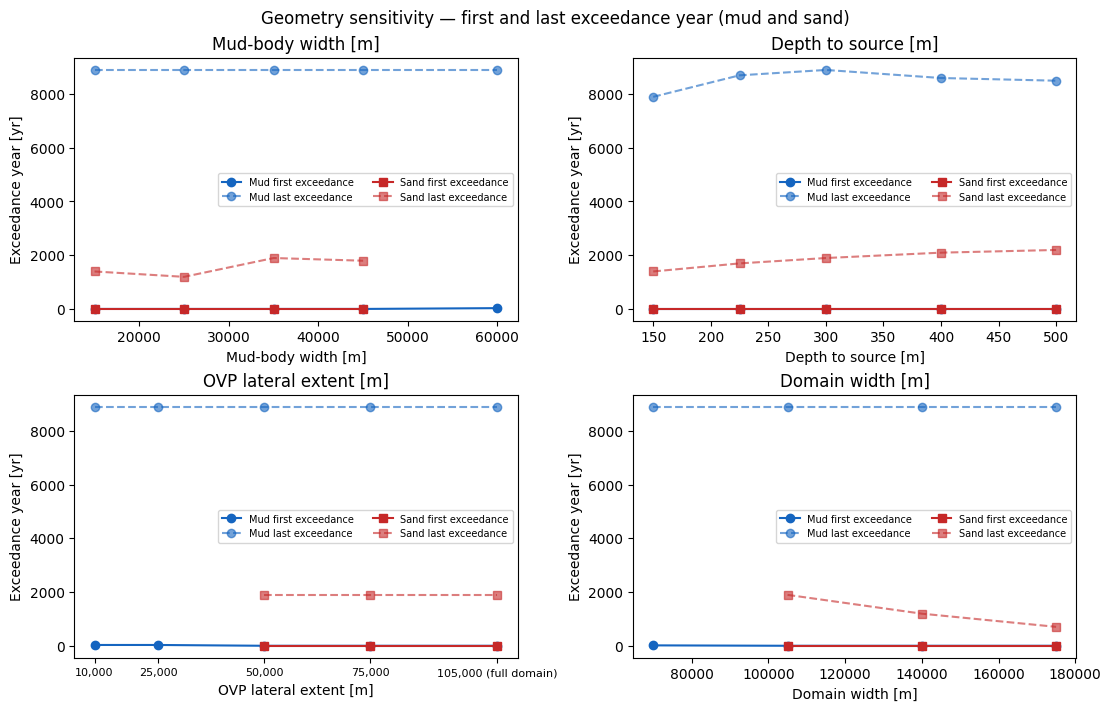

In [12]:
OVP_FULL_DOMAIN_M = 105_000.0

axes_to_plot = [
    ('mud_width',          'Mud-body width [m]'),
    ('depth_to_source',    'Depth to source [m]'),
    ('ovp_lateral_extent', 'OVP lateral extent [m]'),
    ('Lx',                 'Domain width [m]'),
]

MUD_COLOR  = '#1565c0'
SAND_COLOR = '#c62828'

fig, axs = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax, (axis, label) in zip(axs.flat, axes_to_plot):
    sub = df_sens[df_sens['axis'] == axis].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label); continue

    if axis == 'ovp_lateral_extent':
        sub['_x'] = sub[axis].astype(float).where(sub[axis] >= 0, OVP_FULL_DOMAIN_M)
        sub = sub.sort_values('_x')
        x_plot = sub['_x'].values
        finite_vals = sorted(sub.loc[sub[axis] >= 0, axis].unique())
        tick_vals   = list(finite_vals) + [OVP_FULL_DOMAIN_M]
        tick_labels = [f'{int(v):,}' for v in finite_vals] + [f'{int(OVP_FULL_DOMAIN_M):,} (full domain)']
    else:
        sub = sub.sort_values(axis)
        x_plot = sub[axis].values
        tick_vals, tick_labels = None, None

    ax.plot(x_plot, sub['first_exceed_mud_yr'],  '-o', color=MUD_COLOR,
            label='Mud first exceedance',  markersize=6)
    ax.plot(x_plot, sub['last_exceed_mud_yr'],   '--o', color=MUD_COLOR,
            label='Mud last exceedance',   markersize=6, alpha=0.6)
    ax.plot(x_plot, sub['first_exceed_sand_yr'], '-s', color=SAND_COLOR,
            label='Sand first exceedance', markersize=6)
    ax.plot(x_plot, sub['last_exceed_sand_yr'],  '--s', color=SAND_COLOR,
            label='Sand last exceedance',  markersize=6, alpha=0.6)

    if tick_vals is not None:
        ax.set_xticks(tick_vals)
        ax.set_xticklabels(tick_labels, fontsize=8)

    ax.set_xlabel(label)
    ax.set_ylabel('Exceedance year [yr]')
    ax.legend(fontsize=7, ncol=2)
    ax.set_title(label)

fig.suptitle('Geometry sensitivity — first and last exceedance year (mud and sand)')
plt.savefig(FIGURES_DIR / 'fig_geom_last_exceedance_axes.png', dpi=200, bbox_inches='tight')
plt.show()
